LSTM model with 7 feature ('Log_Return', 'Log_HL_Ratio', 'Log_Vol_Change', 'Fwma_10', 'Williams_R', 'Keltner_Width') + Financial News Sentiment

Target: Direction

Importing all the necessary Libraries 

In [1]:
# Standard library
import os
import random
from datetime import datetime, timedelta

# Data manipulation and numerical computing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning preprocessing and metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.utils import class_weight

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import ta
from ta.momentum import WilliamsRIndicator
from ta.volatility import KeltnerChannel

# Financial data
import yfinance as yf

# Common Functions  
import sys
sys.path.append("C:\\FYP\\sxk1332\\Next Day Predictions")
import Common_Functions
import importlib

Removing randomness from the model to enforce consistent results

In [2]:
#Ensures hash-based operations (like in dicts, sets, or some internal functions) are reproducible across runs
os.environ['PYTHONHASHSEED'] = '0'  # For hash-based operations

#Using the same seed ensures any ranom operations like weight initalization or dropout are the same each time
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

#Tensorflow operations can be non-deterministic even with a fixed seed. This code forced TensorFlow to use deterministic algorithms
tf.config.experimental.enable_op_determinism()

In [3]:
#Loading the sentiment CSV file before passing it to the LSTM
sentiment_df = pd.read_csv("C:\\FYP\sxk1332\\Next Day Predictions\\daily_apple_news_sentiment.csv")

#Converts the date column into a proper datetime object
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])

Function to fetch and download data (Apple Stock Price) from Yahoo everyday roughly for the past 10 years 

In [4]:
ticker = 'AAPL'  
data = yf.download(ticker, start="2015-01-01")

#When you first download stock data using yf.download() the resulting dataframe uses date as the index (row labels)
#Here we are moving date from the index into a regular column - this allows you to extract the dates
data.reset_index(inplace=True)

# Flatten the column names if they're MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.head())

#Calculating Ratios from Stationary Price Features
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
data['Log_HL_Ratio'] = np.log(data['High'] / data['Low'])
data['Log_Vol_Change'] = np.log(data['Volume'] / data['Volume'].shift(1))

#Trend Indicator
def fibonacci_weights(n):
    if n == 1:
        return np.array([1.0])
    
    fib = [1, 2] 
    while len(fib) < n:
        fib.append(fib[-1] + fib[-2])
    
    weights = np.array(fib)
    return weights / weights.sum()

weights = fibonacci_weights(10)
fwma = data['Close'].rolling(10).apply(lambda x: np.dot(x, weights), raw=True)
data['Fwma_10'] = data['Close'] / fwma

#Momentum Indicator
data['Williams_R'] = WilliamsRIndicator(data['High'], data['Low'], data['Close'], lbp=14).williams_r()

#Volatility Indicator
kc = KeltnerChannel(
    high=data['High'],
    low=data['Low'],
    close=data['Close'],
    window=20,
    window_atr=10
)

data['Keltner_Width'] = (kc.keltner_channel_hband() - kc.keltner_channel_lband()) / data['Close']

#data.to_csv("Before.csv", index=False)

#Merge sentiment with stock data using left join (add sentiment data where available)
data = data.merge(
    sentiment_df,
    left_on="Date",
    right_on="date",
    how="left"
)

#Add a new column to the original dataframe 
#Not all days have a sentiment value so add a 0 for all missing sentiment days
data["avg_sentiment"] = data["avg_sentiment"].fillna(0)

#The model cannot differentiate between 0 being a sentiment score and 0 being no news 
#so adding a binary column that gives the model context to only look at days with news

#A binary feature that tells the model whether news exists that day
data["has_news"] = (data["avg_sentiment"] != 0).astype(int)

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.fillna(method='ffill', inplace=True) 
data.dropna(inplace=True)  

#Create a dataframe for tomorrows predictions 
data_for_prediction = data.copy()

#Create a dataframe for training only
train_df = data.copy()

#Direction: 1 if tomorrow's close > today's close else 0
train_df["Direction"] = (train_df["Close"].shift(-1) > train_df["Close"]).astype(int)
train_df = train_df.iloc[:-1].reset_index(drop=True)

#train_df.to_csv("After.csv", index=False)

# Define feature 
price_features = ['Log_Return', 'Log_HL_Ratio', 'Log_Vol_Change', 'Fwma_10', 'Williams_R', 'Keltner_Width']
sentiment_features = ['avg_sentiment', 'has_news']

#Extract specific columns from your DataFrame and converts them into a NumPy array.
price_data = train_df[price_features].values
sentiment_data = train_df[sentiment_features].values
target_data = train_df['Direction'].values
datetime_index = train_df['Date'].values

[*********************100%***********************]  1 of 1 completed

Price       Date      Close       High        Low       Open     Volume
0     2015-01-02  24.214895  24.682228  23.776355  24.671153  212818400
1     2015-01-05  23.532719  24.064282  23.346673  23.984547  257142000
2     2015-01-06  23.534941  23.794077  23.173920  23.596956  263188400
3     2015-01-07  23.864948  23.964616  23.632389  23.743131  160423600
4     2015-01-08  24.781897  24.839483  24.075361  24.192749  237458000



C:\Users\Sxk1332\AppData\Local\Temp\ipykernel_29256\1001834061.py:70: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


In [5]:
# Get the number of close prices
print(f"Number of close prices: {len(train_df)}")

Number of close prices: 2832


Splitting the data into a training set (first 85%) and testing set (remaining 15%)

In [6]:
#Defining the split size
#70% of the total data to be used for training, 15% for validation, and 15% for testing
total_size = len(train_df)

train_size = int(len(train_df) * 0.70)
val_size = int(len(train_df) * 0.15)

#Chronogically splitting the data so first 70% is training, the next 15% is validation and the remaining 15% is testing
train_price = price_data[:train_size]
val_price = price_data[train_size:train_size + val_size]
test_price = price_data[train_size + val_size:]

#Split Sentiment Data (no scaling needed)
train_sent = sentiment_data[:train_size]
val_sent = sentiment_data[train_size:train_size + val_size]
test_sent = sentiment_data[train_size + val_size:]

#Split Target Data (no scaling needed)
train_y = target_data[:train_size]
val_y   = target_data[train_size:train_size+val_size]
test_y  = target_data[train_size+val_size:]

print("Total samples:", total_size)

print("\nDataset sizes:")
print(f"Training set   : {len(train_price)} samples ({len(train_price)/total_size:.2%})")
print(f"Validation set : {len(val_price)} samples ({len(val_price)/total_size:.2%})")
print(f"Test set       : {len(test_price)} samples ({len(test_price)/total_size:.2%})")

print("Train:", train_price.shape)
print("Val  :", val_price.shape)
print("Test :", test_price.shape)

print("\nCheck sum:", len(train_price) + len(val_price) + len(test_price))

Total samples: 2832

Dataset sizes:
Training set   : 1982 samples (69.99%)
Validation set : 424 samples (14.97%)
Test set       : 426 samples (15.04%)
Train: (1982, 6)
Val  : (424, 6)
Test : (426, 6)

Check sum: 2832


Normalizing the price data using a StandardScaler. But only using only the training data as the scaler to prevent data leaks. 

In [7]:
#We are now scaling the data feature wise to ensure all features contribute meaningfully
num_features = train_price.shape[1]
scalers = [StandardScaler() for _ in range(num_features)]

# Fit scalers on training data only
for i, scaler in enumerate(scalers):
    scaler.fit(train_price[:, [i]])

# Function to scale data using all scalers
def scale_data(data, scalers):
    return np.hstack([scalers[i].transform(data[:, [i]]) for i in range(len(scalers))])

# Transform all splits
train_price_scaled = scale_data(train_price, scalers)
val_price_scaled = scale_data(val_price, scalers)
test_price_scaled = scale_data(test_price, scalers)

# Training data Mean should be ~0 and Std Dev should be ~1
print(f"Train Scaled -> Mean: {train_price_scaled.mean():.4f}, Std Dev: {train_price_scaled.std():.4f}")
# Val/Test will vary slightly, which is expected
print(f"Val   Scaled -> Mean: {val_price_scaled.mean():.4f}, Std Dev: {val_price_scaled.std():.4f}")
print(f"Test  Scaled -> Mean: {test_price_scaled.mean():.4f}, Std Dev: {test_price_scaled.std():.4f}")

Train Scaled -> Mean: 0.0000, Std Dev: 1.0000
Val   Scaled -> Mean: -0.0918, Std Dev: 0.8321
Test  Scaled -> Mean: -0.0105, Std Dev: 0.9960


In [8]:
#Stack scaled prices with unscaled sentiment
train_final = np.hstack([train_price_scaled, train_sent])
val_final = np.hstack([val_price_scaled, val_sent])
test_final = np.hstack([test_price_scaled, test_sent])

all_cols = price_features + sentiment_features

datasets = {
    "Train": train_final,
    "Validation": val_final,
    "Test": test_final
}

#Loop through the dictionary items
for name, dataset_array in datasets.items():
    rows, cols = dataset_array.shape
    print(f"{name} Set - Rows: {rows}, Columns: {cols}")

Train Set - Rows: 1982, Columns: 8
Validation Set - Rows: 424, Columns: 8
Test Set - Rows: 426, Columns: 8


Creating a Sliding Window to prepare the input data for the LSTM model

In [9]:
def create_multifeature_dataset_with_context(feature_data, target_data, time_step, prev_features=None):
    #Handling context for the validation and test set (stacking the last 24 days from the previous set to the current set)
    if prev_features is not None:
        feature_data = np.vstack([prev_features[-(time_step - 1):], feature_data])
    
    X, y = [] , []
    
    for i in range(time_step - 1, len(feature_data)):
        window = feature_data[i - (time_step - 1) : i + 1] #here we grab all columns and rows per timesteps (rows 0-24 first time)
        X.append(window)
        
        if prev_features is not None:
            y_idx = i - (time_step - 1) #here we predict the target for row 25

        #For the validation and test set we stacked the last 24 days from the previous set to the current set 
        #so to ensure the target (first index in the validation or test set) is aligned we need to use index 24
        else:
            y_idx = i  
            
        if y_idx < len(target_data):
            y.append(target_data[y_idx])
    
    return np.array(X), np.array(y)

time_step = 25

X_train, y_train = create_multifeature_dataset_with_context(train_final, train_y, time_step)

X_val, y_val = create_multifeature_dataset_with_context(val_final, val_y, time_step, prev_features=train_final)

X_test, y_test = create_multifeature_dataset_with_context(test_final, test_y, time_step, prev_features=val_final)

# Check shapes
print("Shapes of the datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}, y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

Shapes of the datasets:
X_train: (1958, 25, 8), y_train: (1958,)
X_val  : (424, 25, 8), y_val  : (424,)
X_test : (426, 25, 8), y_test : (426,)


Here we add class wights - Apple's stock has more ups than downs 
So penalise the model more (with a larger weight) so missing down days 

In [10]:
#Check the raw counts of Up (1) vs Down (0)
classes, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(classes, counts))

print("--- Data Distribution ---")
print(f"Down moves (0): {class_counts.get(0, 0)}")
print(f"Up moves (1):   {class_counts.get(1, 0)}")

#Calculate the weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {int(classes[i]): weights[i] for i in range(len(weights))}

print("\n--- Calculated Weights ---")
for cls, weight in class_weights_dict.items():
    label = "Up" if cls == 1 else "Down"
    print(f"{label} (Class {cls}): {weight:.4f}")

--- Data Distribution ---
Down moves (0): 933
Up moves (1):   1025

--- Calculated Weights ---
Down (Class 0): 1.0493
Up (Class 1): 0.9551


Building and Training the model

In [11]:
model = Sequential()

#Build the model
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add((LSTM(units=32, return_sequences=True)))
model.add(Dropout(0.2))
model.add((LSTM(units=32, return_sequences=False)))
model.add(Dropout(0.2))

#Used a sigmoid function here, so the model is learning is the probability of of up or down higher 
model.add(Dense(units=1, activation='sigmoid'))

#compile the model
model.compile(optimizer=Adam(learning_rate=1e-5), loss='binary_crossentropy', metrics=['accuracy', 'precision', 'recall'])

#Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,          
    patience=3,               
    verbose=1           
)

callbacks = [early_stop, reduce_lr]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), 
    epochs=150,
    batch_size=64,
    class_weight=class_weights_dict,
    shuffle=False,
    callbacks=callbacks,
    verbose=2
)

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test)
print(f"Test Loss (binary crossentropy): {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")

Epoch 1/150


31/31 - 9s - 286ms/step - accuracy: 0.4964 - loss: 0.6994 - precision: 0.5189 - recall: 0.5220 - val_accuracy: 0.4858 - val_loss: 0.7003 - val_precision: 0.5238 - val_recall: 0.6638 - learning_rate: 1.0000e-05


Epoch 2/150


31/31 - 1s - 34ms/step - accuracy: 0.4908 - loss: 0.6986 - precision: 0.5131 - recall: 0.5337 - val_accuracy: 0.4882 - val_loss: 0.7001 - val_precision: 0.5254 - val_recall: 0.6681 - learning_rate: 1.0000e-05


Epoch 3/150


...

31/31 - 1s - 20ms/step - accuracy: 0.4990 - loss: 0.6950 - precision: 0.5197 - recall: 0.5649 - val_accuracy: 0.4764 - val_loss: 0.6945 - val_precision: 0.5170 - val_recall: 0.6552 - learning_rate: 4.8828e-09


 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5312 - loss: 0.6915 - precision: 0.5789 - recall: 0.6111

10/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5102 - loss: 0.6935 - precision: 0.5479 - recall: 0.5961 

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5376 - loss: 0.6930 - precision: 0.5630 - recall: 0.5903


Test Loss (binary crossentropy): 0.6930
Test Accuracy: 0.5376
Test Precision: 0.5630
Test Recall:    0.5903


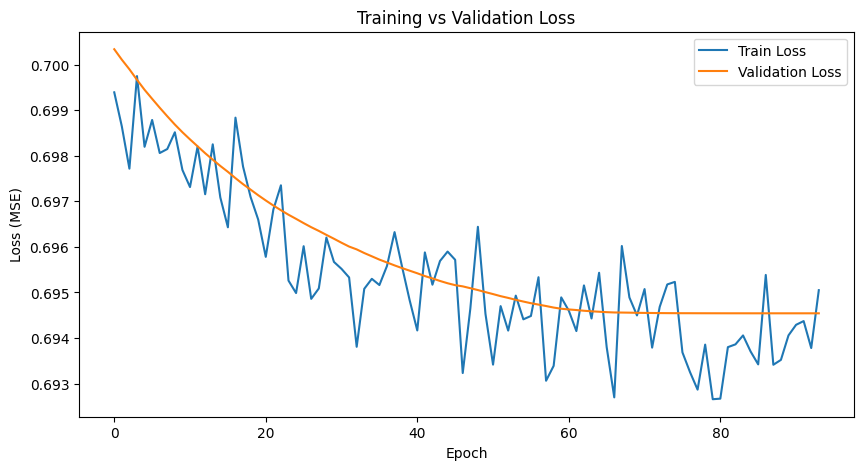

In [12]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

Predictions

In [13]:
# Get probabilities
y_pred_probs = model.predict(X_test)

# Convert to binary direction (1 if prob > 0.5, else 0)
y_pred = (y_pred_probs > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

 1/14 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step

10/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Accuracy : 0.5376
Precision: 0.5630
Recall   : 0.5903


Comparing my LSTM to a basline model that always predicts up

In [14]:
print("Percent of UP days in test set:", np.mean(y_test))

Percent of UP days in test set: 0.5328638497652582


In [15]:
y_pred_always_up = np.ones_like(y_test)

print("Accuracy:", accuracy_score(y_test, y_pred_always_up))
print("Precision:", precision_score(y_test, y_pred_always_up))
print("Recall:", recall_score(y_test, y_pred_always_up))

Accuracy: 0.5328638497652582
Precision: 0.5328638497652582
Recall: 1.0


Using the model to predict the direction of tomorrow:

In [16]:
#Extract the raw feature values from the un-truncated dataframe
price_data_live = data_for_prediction[price_features].values
sentiment_data_live = data_for_prediction[sentiment_features].values

#Scale the price features using the fitted scalers from training
full_price_scaled = scale_data(price_data_live, scalers)

#Combine scaled price features with sentiment features
full_final_live = np.hstack([full_price_scaled, sentiment_data_live])

In [17]:
#Extract the last 25 days for tomorrows prediction
last_window = full_final_live[-time_step:]

# Reshape for LSTM input: (samples, time_steps, features)
X_live = np.reshape(last_window, (1, time_step, full_final_live.shape[1]))

print("Dates and Close Prices used for the prediction window (last {} days):".format(time_step))

# Slice the last 'time_step' rows of the dataframe to get matching dates and prices
prediction_window_df = data_for_prediction.iloc[-time_step:]

for idx, (row_idx, row) in enumerate(prediction_window_df.iterrows()):
    print(f"Day {idx+1:2d} | Date: {row['Date'].date()} | Close Price: {row['Close']:.2f}")

# Specifically highlight the final day (today's close)
print("-" * 50)
print(f"Final Close Price used (Today): {prediction_window_df['Close'].iloc[-1]:.2f}")

Dates and Close Prices used for the prediction window (last 25 days):
Day  1 | Date: 2026-03-24 | Close Price: 251.64
Day  2 | Date: 2026-03-25 | Close Price: 252.62
Day  3 | Date: 2026-03-26 | Close Price: 252.89
Day  4 | Date: 2026-03-27 | Close Price: 248.80
Day  5 | Date: 2026-03-30 | Close Price: 246.63
Day  6 | Date: 2026-03-31 | Close Price: 253.79
Day  7 | Date: 2026-04-01 | Close Price: 255.63
Day  8 | Date: 2026-04-02 | Close Price: 255.92
Day  9 | Date: 2026-04-06 | Close Price: 258.86
Day 10 | Date: 2026-04-07 | Close Price: 253.50
Day 11 | Date: 2026-04-08 | Close Price: 258.90
Day 12 | Date: 2026-04-09 | Close Price: 260.49
Day 13 | Date: 2026-04-10 | Close Price: 260.48
Day 14 | Date: 2026-04-13 | Close Price: 259.20
Day 15 | Date: 2026-04-14 | Close Price: 258.83
Day 16 | Date: 2026-04-15 | Close Price: 266.43
Day 17 | Date: 2026-04-16 | Close Price: 263.40
Day 18 | Date: 2026-04-17 | Close Price: 270.23
Day 19 | Date: 2026-04-20 | Close Price: 273.05
Day 20 | Date: 202

In [18]:
#Generate the prediction probability
prediction_prob = model.predict(X_live)[0][0]
FinalPrediction = ""

#Output the results
last_date = data_for_prediction['Date'].iloc[-1]
prediction_date = last_date + pd.offsets.BDay(1)

print(f"Latest data used for prediction: {last_date.date()}")
print(f"Predicting direction for: {prediction_date.date()}")
print(f"Probability of 'UP' move: {prediction_prob:.4f}")

if prediction_prob > 0.51:
    print("Final Prediction: UP")
    FinalPrediction= "UP"
else:
    print("Final Prediction: DOWN")
    FinalPrediction= "DOWN"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Latest data used for prediction: 2026-04-28
Predicting direction for: 2026-04-29
Probability of 'UP' move: 0.5020
Final Prediction: DOWN


In [19]:
importlib.reload(Common_Functions)

Common_Functions.WriteToDatabase("Update",prediction_date,"LSTM_Direction",str(FinalPrediction))
print("Data Sucessfully Saved")

Data Sucessfully Saved
